In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

Generate new sample data

In [2]:
np.random.seed(613)
x1 = np.arange(50)
y1 = np.random.randint(0, 75,50)
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y2 = np.array([110, 180, 240, 99, 220])

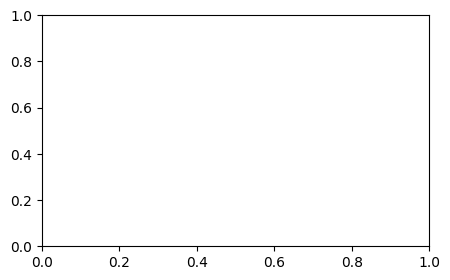

In [3]:
fig, ax = plt.subplots(figsize=(5, 3))

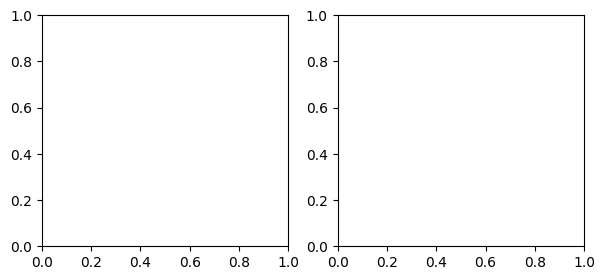

In [4]:
# have 2 plots next to eachother by defining multiple axes and their relative positions
fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))

<BarContainer object of 5 artists>

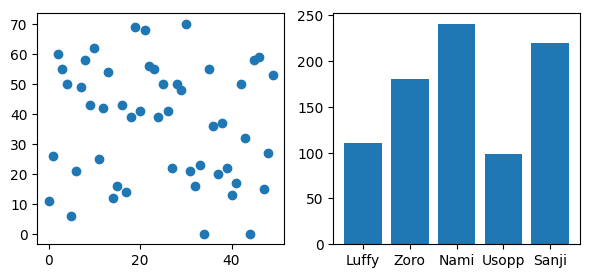

In [5]:
# use the new figure with the two axes and define the types of viz that we want to see in each
fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
ax1.scatter(x1,y1)
ax2.bar(x2,y2)

ACTIVITY: customize the plot based on previous code for adding titles or annotations, or modifying colour, marker type, and fonts - different for each subplot.

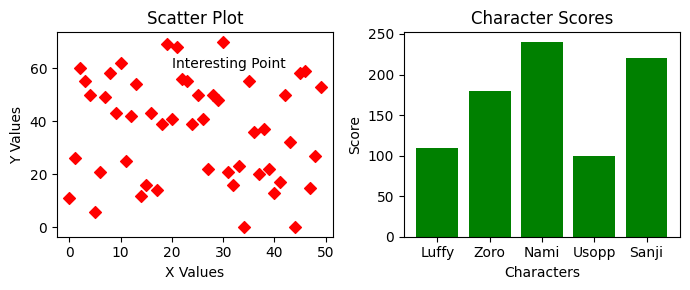

In [6]:
fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))

##################################
ax1.scatter(
    x1,
    y1,
    color="red",
    marker="D"
)

ax1.set_title("Scatter Plot")
ax1.set_xlabel("X Values")
ax1.set_ylabel("Y Values")

ax1.annotate(
    "Interesting Point",
    xy=(20,60)
)

###################################
ax2.bar(
    x2,
    y2,
    color="green"
)

ax2.set_title("Character Scores")
ax2.set_xlabel("Characters")
ax2.set_ylabel("Score")

plt.tight_layout()


<BarContainer object of 5 artists>

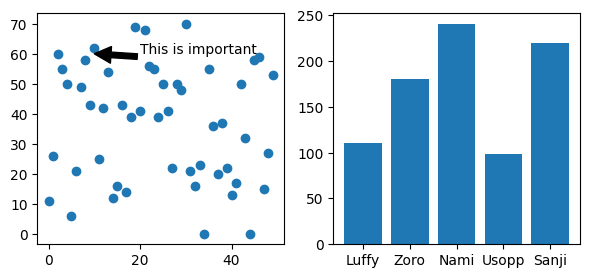

In [7]:
fig, (ax1, ax2) = plt.subplots(ncols =2, nrows =1, figsize = (7,3))
ax1.scatter(x1, y1)
ax1.annotate("This is important", xy = (10,60), xytext=(20,60), arrowprops = dict(facecolor='black'))
ax2.bar(x2, y2)

We can also arrange the subplots within our figure using plt.subplot_mosaic(). This is without a grid arrangement.

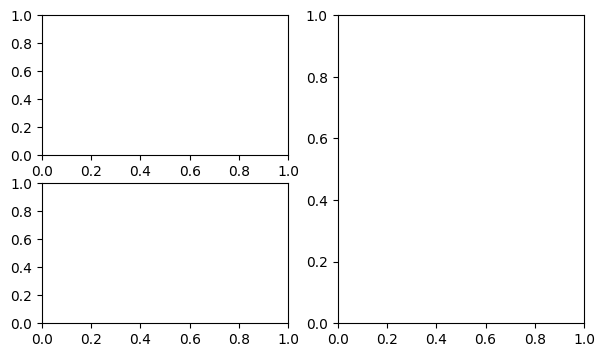

In [8]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                    ['ax2', 'ax3']],
                                    figsize=(7, 4))

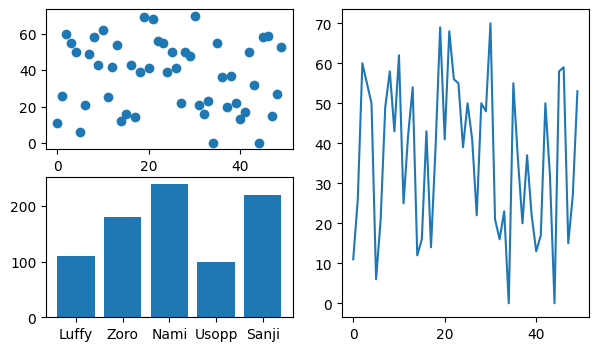

In [9]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                    ['ax2', 'ax3']],
                                    figsize=(7, 4))

# add the data to the subplots the same way as before
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

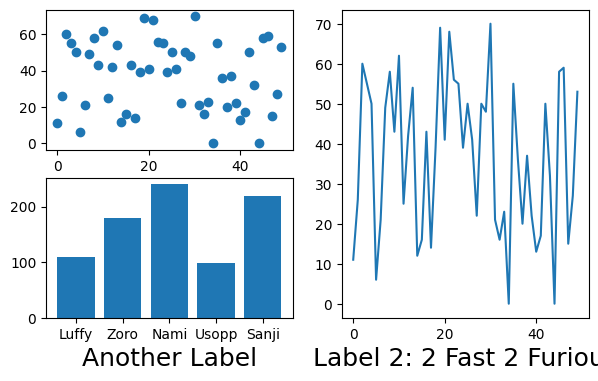

In [10]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                    ['ax2', 'ax3']],
                                    figsize=(7, 4))

# add the data to the subplots the same way as before
someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)

# add some very large x axis titles to the plot
someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18)

Clearly, the axis title for our scatterplot is missing and the axis title for the line plot is cut off..

We need to adjust the layouts -- tight layout and constrained layout

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

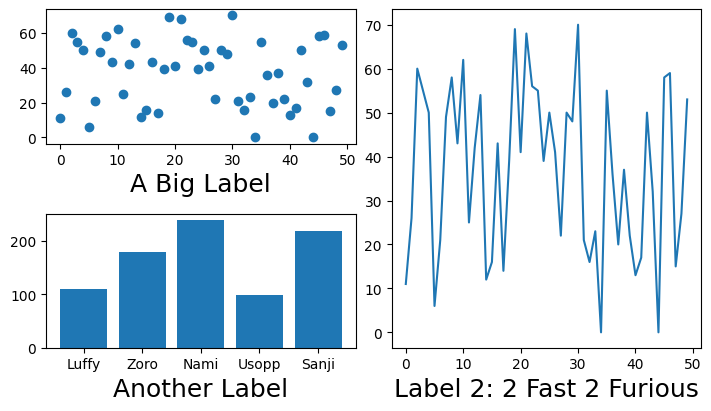

In [11]:
fig, someaxes = plt.subplot_mosaic([['ax1', 'ax3'],
                                    ['ax2', 'ax3']],
                                    figsize=(7, 4),
                                    layout = "constrained")

someaxes["ax1"].scatter(x1,y1)
someaxes["ax2"].bar(x2,y2)
someaxes["ax3"].plot(x1,y1)

someaxes["ax1"].set_xlabel('A Big Label',fontsize=18)
someaxes["ax2"].set_xlabel('Another Label',fontsize=18)
someaxes["ax3"].set_xlabel('Label 2: 2 Fast 2 Furious',fontsize=18)

Multiple viz on one axes object: Call multiple plot methods on the same axes

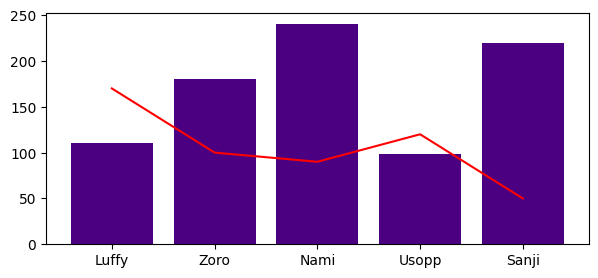

In [12]:
# first make our sample data
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])
y2 = np.array([170, 100, 90, 120, 50])

# define our figure and axes (just one this time)
fig, ax = plt.subplots(figsize=(7, 3))

# now call both bar and plot elements to the same axes (ax)
ax.bar(x, y1,color = "indigo")
ax.plot(x, y2,color = "red")

Add error information - first need to calculate the standard deviation of the data

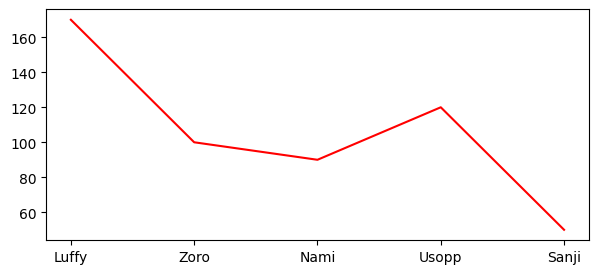

In [13]:
# Calculate the standard deviation of the data
y2_sd = np.std(y2)

# Plot the line as before
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

# this is just the figure we have created before

<ErrorbarContainer object of 3 artists>

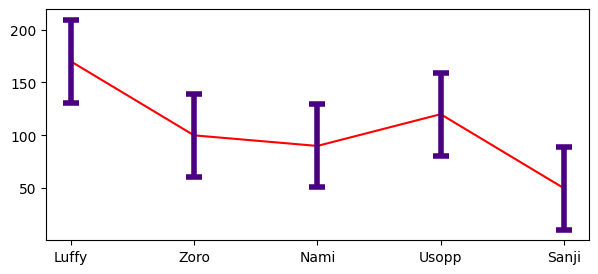

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")
ax.errorbar(x, y2,
            yerr = y2_sd,
            fmt = "none",
            ecolor= "indigo",
            elinewidth= 4,
            capsize = 6,
            capthick= 4)

#fmt - try "o" or "-"" 

<ErrorbarContainer object of 3 artists>

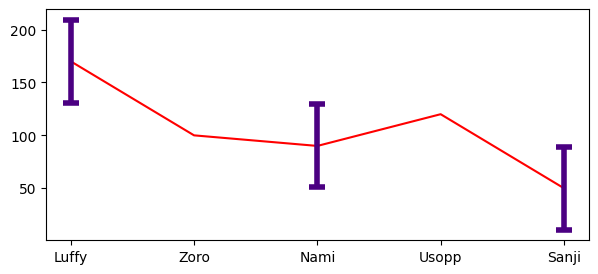

In [15]:
# if we dont want to see error bars for every single point, we can specify intervals using errorevery
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")
ax.errorbar(x, y2,
            yerr = y2_sd,
            fmt = "none",
            ecolor= "indigo",
            elinewidth= 4,
            capsize = 6,
            capthick= 4,
            errorevery=2)

Adding images to plots:

In [16]:
from PIL import Image # to open images
import requests # to get images from URLs
from io import BytesIO # to store images

In [17]:
url = "https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png"
headers = {"User-Agent": "Mozilla/5.0","Accept": "image/*,*/*;q=0.8","Referer": "https://en.wikipedia.org/"}
response = requests.get(url, headers=headers)
image_file = BytesIO(response.content)
image = Image.open(image_file)

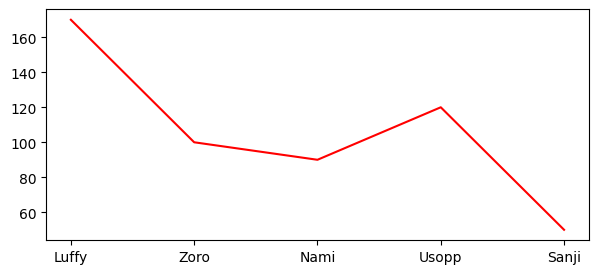

In [18]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

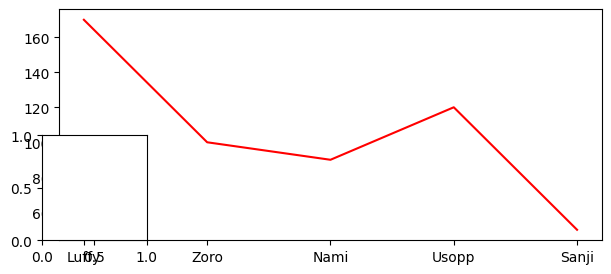

In [19]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")

ax_image = fig.add_axes([0.1, # x coordinate (ON FIGURE, NOT AXES) 
                         0.11, # y coordinate (ON FIGURE, NOT AXES) 
                         0.15, # image width 
                         0.35] # image height
                         )

(np.float64(-0.5), np.float64(219.5), np.float64(425.5), np.float64(-0.5))

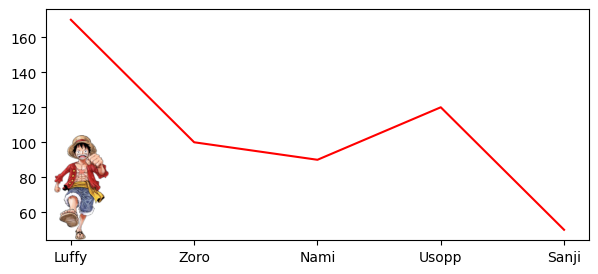

In [20]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(x, y2, color = "red")
ax_image = fig.add_axes([0.1, 0.11, 0.15, 0.35]) # specify the coordinates, we start this figure at 10% from the left side of the figure, and we start it at 11% from the bottom, the figure spans 15% of the whole figure width and the image spans 35% of the figure height
ax_image.imshow(image)
ax_image.axis('off')

Saving our visualizations:

In [21]:


# define where we want to save our visualization
path = '/Users/serenemoussaoui/Documents/Work/DSI - 2026 Certification/visualization/02_activities/assignments/participation'
# can be a full path or a relative path
filename = 'fig1a.png'

In [ ]:
# then save the visualization
fig.savefig(path + filename, dpi=300) # the presentation from lecture said plt.savefig(), it saved an empty png. I changed it to fig.savefig()
# note that path shouldn't end with / since filename starts with it